### RetailLens · Notebook 3 — Customer Lifetime Value Modelling

### What this notebook does
1. Explains what Customer Lifetime Value (CLV) is and why it matters
2. Introduces the **BG/NBD model** — predicts how often a customer will buy in the future
3. Introduces the **Gamma-Gamma model** — predicts how much they'll spend per order
4. Combines both to produce a **12-month CLV prediction per customer**
5. Merges CLV predictions into our RFM segment table
6. Analyses the CLV results by segment

### Why CLV matters for the business
If you only look at historical spend, you miss the future.
A customer who spent £5,000 two years ago and hasn't been back may be worth £0 going forward.
A customer who spent £500 over the last 3 months and buys every 2 weeks might be worth £3,000
in the next 12 months.

CLV answers: **"If I invest £50 in a marketing campaign per customer, which customers
will generate enough future revenue to make that worthwhile?"**

### Step 1 - Load Data and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix
import warnings

In [4]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [5]:
# Load transactions and segments
df  = pd.read_csv('../data/clean_data.csv', parse_dates=['InvoiceDate'])
rfm = pd.read_csv('../data/rfm_segments.csv')

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")
print(f"Transactions: {len(df):,}")
print(f"Customers:    {rfm['Customer ID'].nunique():,}")

Snapshot date: 2011-12-10
Transactions: 805,549
Customers:    5,878


## Step 2 — Why NOT use a simple CLV formula?

A common mistake is to calculate CLV as:
```
CLV = (Average Order Value) × (Purchase Frequency) × (Customer Lifespan)
```

**Problems with this:**
1. It treats all customers as if they'll keep buying forever at the same rate
2. It doesn't account for the fact that some customers have already "churned" (stopped buying)
3. It can't tell the difference between a customer who hasn't bought recently because they're
   gone vs. one who buys infrequently by nature

### The BG/NBD + Gamma-Gamma approach

This is the gold standard for **non-contractual** settings (e-commerce, retail) where
customers can buy at any time without telling you they've "cancelled".

| Model | What it predicts |
|---|---|
| **BG/NBD** (Beta-Geometric / Negative Binomial Distribution) | *How many times* will this customer buy in the next N days? |
| **Gamma-Gamma** | *How much* will they spend per transaction on average? |

Combined: `CLV = predicted purchases × predicted spend per purchase`

### The key insight of BG/NBD
Every customer is either **alive** (still willing to buy) or **dead** (permanently churned).
We can't observe which state they're in — but BG/NBD estimates the probability of each,
given their observed purchase history.

A customer who bought 10 times in year 1 but nothing in 8 months has a high probability
of being "dead". A customer who naturally buys every 6 months and last bought 5 months ago
is probably still "alive".


### Step 3 - Prepare data for the lifetimes library

In [6]:
# The `lifetimes` library needs a specific summary format with these columns:
# - frequency:      number of REPEAT purchases (total purchases - 1)
# - recency:        days between first and last purchase
# - T:              days between first purchase and snapshot date (customer age)
# - monetary_value: average spend per transaction (NOT total spend)

# Note: frequency in lifetimes = repeat purchases (not the same as RFM Frequency!)
# A customer who bought once has frequency = 0 in the lifetimes model.

summary = summary_data_from_transaction_data(
    df,
    customer_id_col   = 'Customer ID',
    datetime_col      = 'InvoiceDate',
    monetary_value_col= 'TotalRevenue',
    observation_period_end = snapshot_date,
    freq              = 'D'   # 'D' means we work in days
)

print(f"Summary shape: {summary.shape}")
print()
print("What each column means:")
print("  frequency      = number of repeat purchases (first purchase not counted)")
print("  recency        = days between first and LAST purchase")
print("  T              = days between first purchase and today (customer age)")
print("  monetary_value = average revenue per transaction")
print()
summary.head(10)

Summary shape: (5878, 4)

What each column means:
  frequency      = number of repeat purchases (first purchase not counted)
  recency        = days between first and LAST purchase
  T              = days between first purchase and today (customer age)
  monetary_value = average revenue per transaction



,frequency,recency,T,monetary_value
Customer ID,,,,
12346,7.0,400.0,726.0,11066.637143
12347,7.0,402.0,405.0,717.398571
12348,4.0,363.0,439.0,449.310000
12349,3.0,571.0,590.0,1120.056667
12350,0.0,0.0,311.0,0.000000
12351,0.0,0.0,376.0,0.000000
12352,8.0,356.0,393.0,338.261250
12353,1.0,204.0,409.0,89.000000
12354,0.0,0.0,233.0,0.000000


In [7]:
# Quick sanity check on the summary data
print(f"Customers with 0 repeat purchases (one-time buyers): {(summary['frequency'] == 0).sum():,}")
print(f"Customers with 1+ repeat purchases:                   {(summary['frequency'] > 0).sum():,}")
print()
print("Summary statistics:")
summary.describe().round(2)

Customers with 0 repeat purchases (one-time buyers): 1,689
Customers with 1+ repeat purchases:                   4,189

Summary statistics:


,frequency,recency,T,monetary_value
count,5878.00,5878.00,5878.00,5878.00
mean,4.63,273.39,475.26,319.05
std,10.00,258.96,223.09,2256.85
min,0.00,0.00,1.00,0.00
25%,0.00,0.00,314.00,0.00
50%,2.00,221.00,531.00,213.63
75%,5.00,512.00,669.00,376.21
max,254.00,738.00,739.00,168469.60


## Step 4 — Fit the BG/NBD model

The BG/NBD model learns 4 parameters from the data:
- `r`, `alpha` — shape the distribution of purchase rates across customers
- `a`, `b`     — shape the distribution of dropout (churn) rates

`penalizer_coef=0.01` is a regularisation term — it prevents the model from
overfitting to outlier customers with unusual behaviour patterns.


In [8]:
# Initialise the BG/NBD model.
# BG/NBD models repeat purchase behaviour for non-contractual customers,
# where customers can become inactive without explicitly cancelling.
bgf = BetaGeoFitter(penalizer_coef=0.01)

# Fit the model using customer-level transaction summary data
# frequency = number of repeat purchases made by the customer
# recency   = time between the customer's first and last purchase
# T         = time between the customer's first purchase and the end of the observation period
bgf.fit(
    summary['frequency'],
    summary['recency'],
    summary['T']
)

# Confirm that the model fitting process completed successfully
print("BG/NBD model fitted successfully")
print()

# Display the learned model parameters
# These parameters are estimated from the data during model training
print("Learned parameters:")

# r and alpha control the distribution of customer purchase rates
# They help the model understand how frequently customers make repeat purchases
print(f"  r     = {bgf.params_['r']:.4f}  (purchase rate shape)")
print(f"  alpha = {bgf.params_['alpha']:.4f}  (purchase rate scale)")

# a and b control the dropout probability distribution
# They help the model estimate whether a customer is still active or has become inactive
print(f"  a     = {bgf.params_['a']:.4f}  (dropout rate shape)")
print(f"  b     = {bgf.params_['b']:.4f}  (dropout rate scale)")

print()

BG/NBD model fitted successfully

Learned parameters:
  r     = 0.6514  (purchase rate shape)
  alpha = 61.9071  (purchase rate scale)
  a     = 0.0465  (dropout rate shape)
  b     = 0.6033  (dropout rate scale)



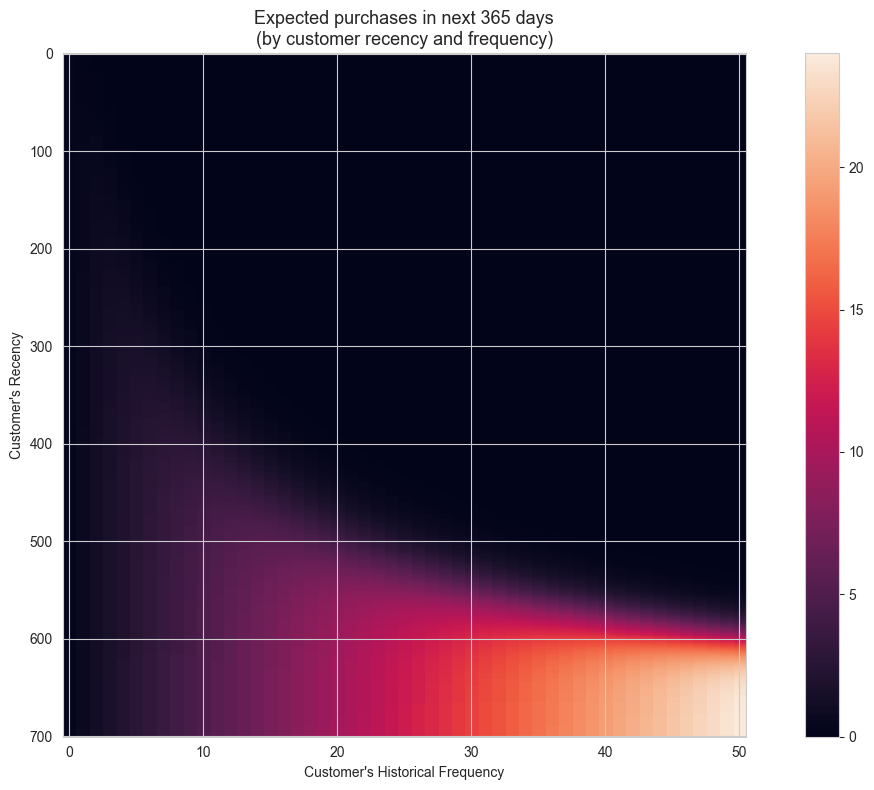

Notes:
  Brighter colours = more predicted future purchases
  Top-right corner: bought many times AND recently → high future value
  Bottom-right: bought many times but a long time ago → probably churned


In [9]:
# Plot BG/NBD frequency-recency matrix to visualise expected future purchases
# The model estimates how many purchases customers are likely to make
# over the next 365 days based on their historical frequency and recency

fig = plt.figure(figsize=(12, 8))

plot_frequency_recency_matrix(
    bgf,              # fitted BG/NBD model
    T=365,            # future prediction period in days
    max_frequency=50, # limit displayed repeat-purchase frequency
    max_recency=700   # limit displayed customer recency
)

plt.title(
    'Expected purchases in next 365 days\n(by customer recency and frequency)',
    fontsize=13
)

plt.tight_layout()
plt.show()

print("Notes:")
print("  Brighter colours = more predicted future purchases")
print("  Top-right corner: bought many times AND recently → high future value")
print("  Bottom-right: bought many times but a long time ago → probably churned")

In [10]:
# Estimate the expected number of purchases for each customer
# over the next 12 months using the fitted BG/NBD model.
summary['predicted_purchases_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t=365,                          # prediction horizon in days
    frequency=summary['frequency'], # repeat purchases excluding the first order
    recency=summary['recency'],     # time between first and last purchase
    T=summary['T']                  # customer age: first purchase to observation end
)

print("Top 10 customers by predicted future purchases:")

# Select the customers with the highest predicted purchase count.
# Display only key model input columns and the prediction output.
top_buyers = summary.nlargest(10, 'predicted_purchases_12m')[
    ['frequency', 'recency', 'T', 'predicted_purchases_12m']
].round(2)

print(top_buyers)

Top 10 customers by predicted future purchases:
             frequency  recency      T  predicted_purchases_12m
Customer ID                                                    
14911            254.0    737.0  739.0                   114.94
12748            201.0    735.0  736.0                    91.36
15311            195.0    738.0  739.0                    88.31
17841            192.0    736.0  738.0                    87.06
14606            180.0    735.0  737.0                    81.73
13089            131.0    735.0  738.0                    59.48
14527            120.0    735.0  738.0                    54.51
14156            120.0    729.0  739.0                    54.38
12971             98.0    721.0  725.0                    45.29
13798             98.0    730.0  732.0                    44.90


## Step 5 — Fit the Gamma-Gamma Model

The **Gamma-Gamma model** estimates each customer’s expected **average transaction value**

This model is used together with the BG/NBD model:

- **BG/NBD** predicts expected future purchases
- **Gamma-Gamma** predicts expected spend per purchase

The model is fitted only on **repeat customers** (`frequency > 0`), because customers with a single purchase do not provide enough history to estimate their typical spending pattern.

The Gamma-Gamma model assumes that purchase frequency and monetary value are approximately independent. This assumption is generally reasonable for many retail datasets, but it should be checked before modelling

In [11]:
# Use only repeat buyers for Gamma-Gamma modelling
repeat_buyers = summary[summary['frequency'] > 0]

print(f"Repeat buyers: {len(repeat_buyers):,} out of {len(summary):,} total customers")
print()

# Fit Gamma-Gamma model to estimate expected average transaction value
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    repeat_buyers['frequency'],       # repeat purchases excluding first order
    repeat_buyers['monetary_value']   # average transaction value
)

print("Gamma-Gamma model fitted ✓")
print()

# Show learned model parameters
print("Learned parameters:")
for param, val in ggf.params_.items():
    print(f"  {param} = {val:.4f}")

Repeat buyers: 4,189 out of 5,878 total customers

Gamma-Gamma model fitted ✓

Learned parameters:
  p = 3.7792
  q = 0.3365
  v = 3.6820


## Step 6 — Combine both models to predict CLV

In [12]:
# Create a boolean mask to identify repeat buyers
# Gamma-Gamma CLV can only be calculated for customers with repeat purchases
repeat_mask = summary['frequency'] > 0

# Estimate 12-month customer lifetime value using the fitted BG/NBD
# and Gamma-Gamma models
#
# BG/NBD estimates expected future purchase count
# Gamma-Gamma estimates expected average transaction value
# CLV combines both:
# expected future purchases × expected average transaction value
#
# time=12 means the prediction horizon is 12 months
# freq='D' tells lifetimes that recency and T are measured in days
# discount_rate=0.01 applies a 1% monthly discount rate to future revenue
clv_12m = ggf.customer_lifetime_value(
    bgf,
    summary.loc[repeat_mask, 'frequency'],
    summary.loc[repeat_mask, 'recency'],
    summary.loc[repeat_mask, 'T'],
    summary.loc[repeat_mask, 'monetary_value'],
    time=12,
    freq='D',
    discount_rate=0.01
)

# Initialise CLV column with 0 for all customers
# One-time buyers keep CLV = 0 because Gamma-Gamma was not fitted for them
summary['CLV_12m'] = 0.0

# Assign predicted CLV values only to repeat buyers
summary.loc[repeat_mask, 'CLV_12m'] = clv_12m

# Remove very small negative values that may occur due to numerical estimation
summary['CLV_12m'] = summary['CLV_12m'].clip(lower=0)

# Confirm CLV predictions were generated
print("CLV predictions generated")
print()

# Display summary statistics for predicted 12-month CLV
print("CLV summary statistics:")
print(summary['CLV_12m'].describe().round(2))
print()

# Estimate total predicted customer revenue over the next 12 months.
print(f"Total predicted revenue across all customers (12m): £{summary['CLV_12m'].sum():,.0f}")

CLV predictions generated

CLV summary statistics:
count      5878.00
mean       1483.73
std        8238.46
min           0.00
25%           0.00
50%         403.77
75%        1290.33
max      382132.19
Name: CLV_12m, dtype: float64

Total predicted revenue across all customers (12m): £8,721,356


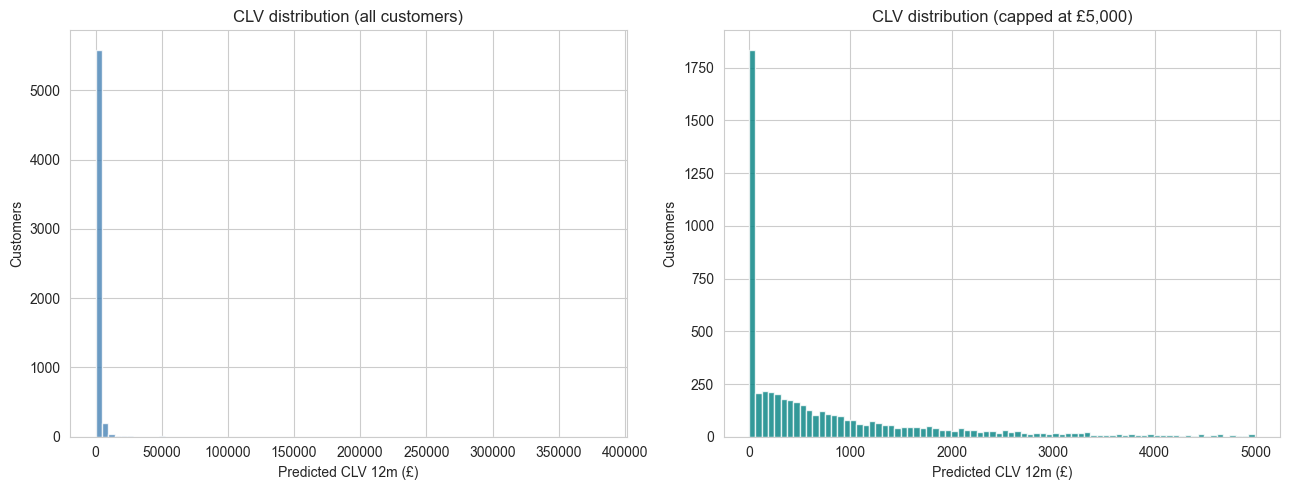

In [13]:
# Plot the distribution of predicted 12-month CLV values
# CLV distributions are often right-skewed, meaning most customers have
# relatively low predicted value while a small number have very high value
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot full CLV distribution across all customers
# This helps identify the overall spread and extreme high-value customers
axes[0].hist(
    summary['CLV_12m'],
    bins=80,
    color='steelblue',
    alpha=0.8
)
axes[0].set_title('CLV distribution (all customers)')
axes[0].set_xlabel('Predicted CLV 12m (£)')
axes[0].set_ylabel('Customers')

# Plot a capped / zoomed-in version of the distribution
# Customers with CLV >= £5,000 are excluded only for visualisation purposes
# so the main customer population is easier to inspect
axes[1].hist(
    summary[summary['CLV_12m'] < 5000]['CLV_12m'],
    bins=80,
    color='teal',
    alpha=0.8
)
axes[1].set_title('CLV distribution (capped at £5,000)')
axes[1].set_xlabel('Predicted CLV 12m (£)')
axes[1].set_ylabel('Customers')

# Improve spacing between the two plots and display the figure
plt.tight_layout()
plt.show()

### Step 7 — Merge CLV into the RFM segments table

In [14]:
# Merge predicted purchase count and 12-month CLV into the RFM segmentation table
# summary contains the model outputs, while rfm contains customer RFM metrics and segments
rfm_clv = rfm.merge(
    summary[['predicted_purchases_12m', 'CLV_12m']].reset_index(),  # convert Customer ID index into a column
    on='Customer ID',                                                # join using unique customer identifier
    how='left'                                                       # keep all customers from the RFM table
)

# Replace missing prediction values with 0
# Missing values may occur for customers who were not eligible for CLV modelling
rfm_clv['CLV_12m'] = rfm_clv['CLV_12m'].fillna(0)
rfm_clv['predicted_purchases_12m'] = rfm_clv['predicted_purchases_12m'].fillna(0)

# Check the final customer-level dataset dimensions and column names
print(f"Final table shape: {rfm_clv.shape}")
print(f"Columns: {rfm_clv.columns.tolist()}")

# Preview the first 10 rows of the enriched RFM + CLV table (round for presentation)
rfm_clv.head(10).round({
    'predicted_purchases_12m': 2,
    'CLV_12m': 2
})

Final table shape: (5878, 8)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'predicted_purchases_12m', 'CLV_12m']


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,predicted_purchases_12m,CLV_12m
0,12346,326,12,77556.46,1,Loyal Customers,2.47,25962.37
1,12347,2,8,5633.32,1,Loyal Customers,5.84,3981.25
2,12348,75,5,2019.40,1,Loyal Customers,3.24,1413.95
3,12349,19,4,4428.69,1,Loyal Customers,1.98,2179.24
4,12350,310,1,334.40,0,Lost / Inactive,0.00,0.00
5,12351,375,1,300.93,0,Lost / Inactive,0.00,0.00
6,12352,36,10,2849.84,1,Loyal Customers,6.74,2161.11
7,12353,204,2,406.76,0,Lost / Inactive,1.05,108.76
8,12354,232,1,1079.40,1,Loyal Customers,0.00,0.00
9,12355,214,2,947.61,1,Loyal Customers,0.82,423.78


In [16]:
# CLV by segment — the key business insight
seg_clv = rfm_clv.groupby('Segment').agg(
    Customers           = ('Customer ID', 'count'),
    Avg_Recency         = ('Recency',     'mean'),
    Avg_Frequency       = ('Frequency',   'mean'),
    Avg_Historical_Spend= ('Monetary',    'mean'),
    Avg_CLV_12m         = ('CLV_12m',     'mean'),
    Total_CLV_12m       = ('CLV_12m',     'sum'),
).round(1)

print("Average CLV by segment:")
print(seg_clv)

Average CLV by segment:
                 Customers  Avg_Recency  Avg_Frequency  Avg_Historical_Spend  \
Segment                                                                        
Champions               24         21.4          152.1              134898.1   
Lost / Inactive       2283        418.1            1.9                 543.4   
Loyal Customers       3571         64.0            8.1                3714.7   

                 Avg_CLV_12m  Total_CLV_12m  
Segment                                      
Champions            55447.1      1330730.4  
Lost / Inactive         96.7       220755.5  
Loyal Customers       2007.8      7169870.5  


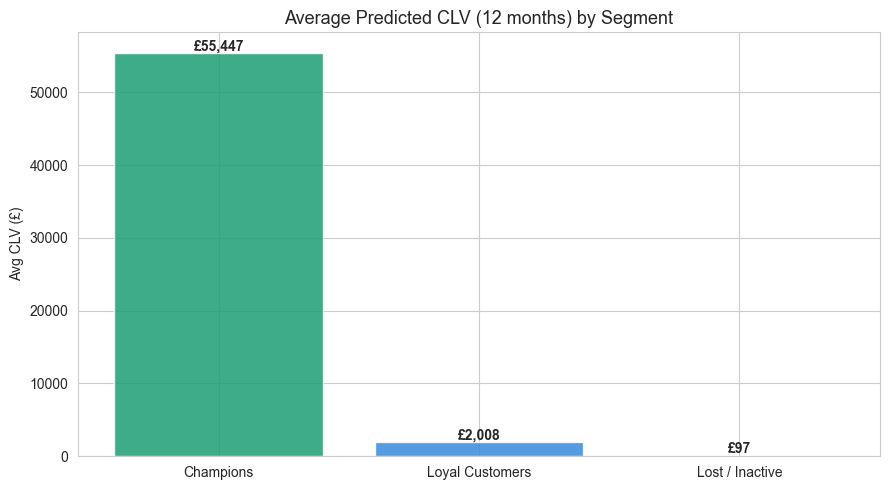

In [18]:
# Define consistent colours for each RFM segment
# Using the same colours across charts improves readability and dashboard consistency
seg_colors = {
    'Champions': '#1D9E75',
    'Loyal Customers': '#378ADD',
    'Lost / Inactive': '#888780'
}

# Calculate average predicted 12-month CLV for each customer segment
# Sorting from highest to lowest makes the business ranking easier to interpret
clv_means = (
    rfm_clv
    .groupby('Segment')['CLV_12m']
    .mean()
    .reset_index()
    .sort_values('CLV_12m', ascending=False)
)

# Create bar chart for average CLV by segment
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    clv_means['Segment'],
    clv_means['CLV_12m'],
    color=[seg_colors[s] for s in clv_means['Segment']],
    alpha=0.85
)

# Add chart title and y-axis label
ax.set_title('Average Predicted CLV (12 months) by Segment', fontsize=13)
ax.set_ylabel('Avg CLV (£)')

# Add value labels above each bar
# This makes the exact average CLV visible without needing to read the axis
for bar, val in zip(bars, clv_means['CLV_12m']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'£{val:,.0f}',
        ha='center',
        fontweight='bold'
    )

# Adjust spacing and display the chart
plt.tight_layout()
plt.show()

In [19]:
# Save the final enriched customer table
# This table combines RFM metrics, customer segments
# predicted future purchases, and 12-month CLV
rfm_clv.to_csv('../data/rfm_clv.csv', index=False)

# Confirm the file path and display final column names
print("Saved: ../data/rfm_clv.csv")
print(f"Columns: {rfm_clv.columns.tolist()}")

# Display the top 10 customers ranked by predicted 12-month CLV
# These customers represent the highest expected future value
print("\nTop 10 customers by predicted CLV:")

rfm_clv.nlargest(10, 'CLV_12m')[
    ['Customer ID', 'Segment', 'Recency', 'Frequency', 'Monetary', 'CLV_12m']
].round(2)

Saved: ../data/rfm_clv.csv
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'predicted_purchases_12m', 'CLV_12m']

Top 10 customers by predicted CLV:


,Customer ID,Segment,Recency,Frequency,Monetary,CLV_12m
4061,16446,Loyal Customers,1,2,168472.50,382132.19
5692,18102,Champions,1,145,608821.65,256377.29
2277,14646,Champions,2,151,528602.52,220595.69
5050,17450,Loyal Customers,8,51,246973.09,141552.49
1731,14096,Loyal Customers,4,17,65164.79,135978.29
1789,14156,Champions,10,156,313946.37,131388.46
2538,14911,Champions,1,398,295972.63,123712.28
68,12415,Loyal Customers,24,28,144458.37,82941.22
1331,13694,Champions,4,143,196482.81,82083.68
5109,17511,Loyal Customers,3,60,175603.55,73265.11
